# Minneapolis Police Stop Analysis

---
## **Early Steps**
* The [MplsStops](https://rdrr.io/cran/carData/man/MplsStops.html) dataset will be used
* The following python libraries will be used: pandas, matplotlib, statsmodels, and geopandas.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from pathlib import Path
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.contingency_tables import Table, StratifiedTable

# Load raw data
dfRaw = pd.read_csv("MplsStops.csv")
dfRaw.head()

,Unnamed: 0,idNum,date,problem,MDC,citationIssued,personSearch,vehicleSearch,preRace,race,gender,lat,long,policePrecinct,neighborhood
0,6823,17-000003,2017-01-01 00:00:42,suspicious,MDC,NaN,NO,NO,Unknown,Unknown,Unknown,44.966617,-93.246458,1,Cedar Riverside
1,6824,17-000007,2017-01-01 00:03:07,suspicious,MDC,NaN,NO,NO,Unknown,Unknown,Male,44.980450,-93.271340,1,Downtown West
2,6825,17-000073,2017-01-01 00:23:15,traffic,MDC,NaN,NO,NO,Unknown,White,Female,44.948350,-93.275380,5,Whittier
3,6826,17-000092,2017-01-01 00:33:48,suspicious,MDC,NaN,NO,NO,Unknown,East African,Male,44.948360,-93.281350,5,Whittier
4,6827,17-000098,2017-01-01 00:37:58,traffic,MDC,NaN,NO,NO,Unknown,White,Female,44.979078,-93.262076,1,Downtown West


---
### Summary of raw data:
We will be collecting the following:
1) A description of each column (data type/rows) using df.info()
2) A summary of the categorical data
3) A summary of the quantitative data using df.desribe()

In [38]:
# Define variable types conceptually
categorical = [
    "problem", "MDC", "citationIssued",
    "personSearch", "vehicleSearch", "preRace",
    "race", "gender", "policePrecinct", "neighborhood"
]

quantitative = ["lat", "long"]

print("Column description and row counts:")
dfRaw.info()

print("\n-----------------------------")
print("Summary of categorical data:")
for column in categorical:
    print(f"___ {column} ___")
    print(dfRaw[column].value_counts(dropna=False), "\n")

print("\n-----------------------------")
print("Summary of quantitative data:")
display(dfRaw[quantitative].describe())

print("\n-----------------------------")
print("Missing values summary:")
missing_summary = pd.DataFrame({
    "missing_count": dfRaw.isna().sum(),
    "missing_percent": (dfRaw.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)

display(missing_summary)

print("\n-----------------------------")
print("Duplicate idNum count:")
print(dfRaw["idNum"].duplicated().sum())

Column description and row counts:
<class 'pandas.DataFrame'>
RangeIndex: 51920 entries, 0 to 51919
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      51920 non-null  int64  
 1   idNum           51920 non-null  str    
 2   date            51920 non-null  str    
 3   problem         51920 non-null  str    
 4   MDC             51920 non-null  str    
 5   citationIssued  19110 non-null  str    
 6   personSearch    43699 non-null  str    
 7   vehicleSearch   43699 non-null  str    
 8   preRace         43699 non-null  str    
 9   race            43699 non-null  str    
 10  gender          43638 non-null  str    
 11  lat             51920 non-null  float64
 12  long            51920 non-null  float64
 13  policePrecinct  51920 non-null  int64  
 14  neighborhood    51920 non-null  str    
dtypes: float64(2), int64(2), str(11)
memory usage: 5.9 MB

-----------------------------
Summary of c

,lat,long
count,51920.000000,51920.000000
mean,44.973966,-93.272800
std,0.031021,0.023827
min,44.890460,-93.329154
25%,44.949260,-93.289833
50%,44.975300,-93.276130
75%,44.999135,-93.254971
max,45.051240,-93.198869



-----------------------------
Missing values summary:


,missing_count,missing_percent
citationIssued,32810,63.19
gender,8282,15.95
personSearch,8221,15.83
race,8221,15.83
preRace,8221,15.83
vehicleSearch,8221,15.83
Unnamed: 0,0,0.00
problem,0,0.00
MDC,0,0.00
idNum,0,0.00



-----------------------------
Duplicate idNum count:
0


---
### Data Cleaning:

It is clear that many of the qualitative columns need cleaning due to NaN/"Unknown" values. Typically, rows with these values should be deemed invalid as they represent an error in the collection phase. There are, however, some exceptions that can be made for this analysis. 

* The first exception will be made for the "preRace" column as there are over 28,000 rows with "Unknown" values for it; this is plausible as cops might really not know the person's race before pulling them over in some cases. Even in the occasion they do know their races beforehand and fail to report, the remainder of the data shouldn't be invalidated.

* An exception will also be made towards the "gender" variable with "Unknown" rows since it is irrelevant in this exploration.

* Additionally, it can be noted that most of the rows in "citationIssued" are left as NaN, which is probably cause by police officers submitting this field as blank when not issuing citations. If all other invalid rows are removed, it is likely that the remaining NaN rows for this column mean that no citation was issued.


Overall, these are the categorical columns with some affected data:

* citationIssued
* personSearch
* vehicleSearch
* preRace
* race
* gender

As for the quantitative data, the values seem to be fine and contain no outliers.

The final problem is with how some of the data is represented.
1) The columns with YES/NO data are also treated as strings, to make their usage easier, they will be converted into booleans.
2) The "date" column is represented as a string, and month, date, as well as time are all in the same column. Ideally we transform this complex numerical column into three categorical columns: month (Jan-Dec), weekday(Mon-Sun), and time(Morning, Afternoon, Night) Most importantly, some date values contain time while others don't. This will be addressed by adding a fourth value to the time column: "Invalid".

In [39]:
df_base = dfRaw.copy()

# Remove accidental index column if present
df_base = df_base.drop(columns=["Unnamed: 0"], errors="ignore")

# Clean column names
df_base.columns = df_base.columns.str.strip()

# Clean string/object columns
for col in df_base.select_dtypes(include=["object", "string"]).columns:
    df_base[col] = df_base[col].astype("string").str.strip()

# Convert date to datetime
df_base["date"] = pd.to_datetime(df_base["date"], errors="coerce")

# Create date/time variables for possible exploratory analysis
df_base["month"] = df_base["date"].dt.month_name()
df_base["weekday"] = df_base["date"].dt.day_name()
df_base["hour"] = df_base["date"].dt.hour

# Create time-of-day variable
df_base["daytime"] = pd.NA

df_base.loc[(df_base["hour"] >= 6) & (df_base["hour"] < 14), "daytime"] = "Morning"
df_base.loc[(df_base["hour"] >= 14) & (df_base["hour"] < 22), "daytime"] = "Afternoon"
df_base.loc[(df_base["hour"] >= 22) | (df_base["hour"] < 6), "daytime"] = "Night"

# Convert to category for cleaner summaries
df_base["daytime"] = df_base["daytime"].astype("category")

# Helper function for YES/NO variables
def yes_no_to_bool(series):
    return series.map({"YES": True, "NO": False})

print("Base dataframe info:")
df_base.info()

print("\nMonth counts:")
print(df_base["month"].value_counts(dropna=False))

print("\nWeekday counts:")
print(df_base["weekday"].value_counts(dropna=False))

print("\nDaytime counts:")
print(df_base["daytime"].value_counts(dropna=False))

Base dataframe info:
<class 'pandas.DataFrame'>
RangeIndex: 51920 entries, 0 to 51919
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   idNum           51920 non-null  string        
 1   date            51919 non-null  datetime64[us]
 2   problem         51920 non-null  string        
 3   MDC             51920 non-null  string        
 4   citationIssued  19110 non-null  string        
 5   personSearch    43699 non-null  string        
 6   vehicleSearch   43699 non-null  string        
 7   preRace         43699 non-null  string        
 8   race            43699 non-null  string        
 9   gender          43638 non-null  string        
 10  lat             51920 non-null  float64       
 11  long            51920 non-null  float64       
 12  policePrecinct  51920 non-null  int64         
 13  neighborhood    51920 non-null  string        
 14  month           51919 non-null  str         

#### Thoughts on Data Cleaning
After cleaning data very liberally we are left with 34,434 entries: more than half of the raw data is still present. This amount of rows is also large enough to perform good statistical analyses.

## **Initial Analyses** 
### (Univariate)

To get some broad insights on the Minneapolis stops data, we will look at the following population proportions: Race and Problem.

A confidence interval for all the population proportions will be calculated. The Wilson score will be used since it is more accurate for values farther away from 0.5 (unlike the Wald score).

In [40]:
# Analysis-specific cleaning: race only
df_race = df_base.dropna(subset=["race"]).copy()
df_race = df_race[df_race["race"] != "Unknown"].copy()

total_race = len(df_race)
race_counts = df_race["race"].value_counts()

race_intervals = proportion_confint(
    count=race_counts,
    nobs=total_race,
    alpha=0.05,
    method="wilson"
)

race_df = pd.DataFrame({
    "race": race_counts.index,
    "count": race_counts.values,
    "proportion": race_counts.values / total_race,
    "lower": race_intervals[0],
    "upper": race_intervals[1]
})

race_df["percent"] = race_df["proportion"] * 100
race_df["lower_percent"] = race_df["lower"] * 100
race_df["upper_percent"] = race_df["upper"] * 100

race_df

,race,count,proportion,lower,upper,percent,lower_percent,upper_percent
race,,,,,,,,
Black,Black,15220,0.441415,0.436181,0.446663,44.141531,43.618090,44.666278
White,White,11703,0.339414,0.334434,0.344430,33.941415,33.443431,34.442977
East African,East African,2188,0.063457,0.060932,0.066079,6.345708,6.093222,6.607919
Latino,Latino,1858,0.053886,0.051552,0.056320,5.388631,5.155234,5.631967
Native American,Native American,1516,0.043968,0.041854,0.046183,4.396752,4.185380,4.618284
Other,Other,1348,0.039095,0.037100,0.041193,3.909513,3.710013,4.119282
Asian,Asian,647,0.018765,0.017385,0.020251,1.87645,1.738493,2.025129


---
### Plotting CIs:
#### Race:

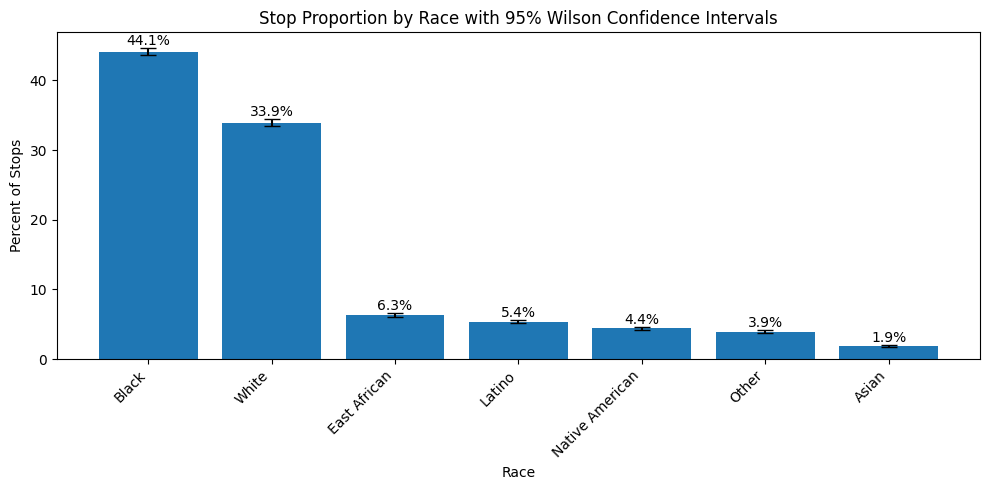

In [41]:
# Error bars in percentage units
lower_error = race_df["percent"] - race_df["lower_percent"]
upper_error = race_df["upper_percent"] - race_df["percent"]
errors = [lower_error, upper_error]

plt.figure(figsize=(10, 5))

bars = plt.bar(
    race_df["race"],
    race_df["percent"],
    yerr=errors,
    capsize=6
)

plt.title("Stop Proportion by Race with 95% Wilson Confidence Intervals")
plt.ylabel("Percent of Stops")
plt.xlabel("Race")
plt.bar_label(bars, fmt="%.1f%%")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

####

,problem,count,proportion,lower,upper,percent,lower_percent,upper_percent
problem,,,,,,,,
traffic,traffic,26098,0.502658,0.498357,0.506958,50.265794,49.835714,50.695833
suspicious,suspicious,25822,0.497342,0.493042,0.501643,49.734206,49.304167,50.164286


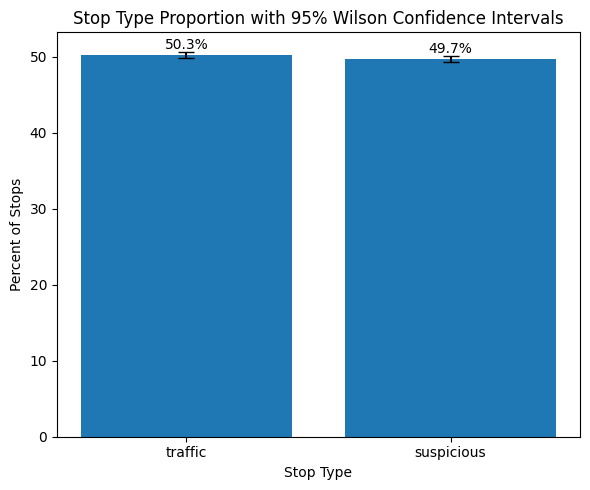

In [42]:
# Analysis-specific cleaning: problem only
df_problem = df_base.dropna(subset=["problem"]).copy()

total_problem = len(df_problem)
problem_counts = df_problem["problem"].value_counts()

problem_intervals = proportion_confint(
    count=problem_counts,
    nobs=total_problem,
    alpha=0.05,
    method="wilson"
)

problem_df = pd.DataFrame({
    "problem": problem_counts.index,
    "count": problem_counts.values,
    "proportion": problem_counts.values / total_problem,
    "lower": problem_intervals[0],
    "upper": problem_intervals[1]
})

problem_df["percent"] = problem_df["proportion"] * 100
problem_df["lower_percent"] = problem_df["lower"] * 100
problem_df["upper_percent"] = problem_df["upper"] * 100

display(problem_df)

# Graph
lower_error = problem_df["percent"] - problem_df["lower_percent"]
upper_error = problem_df["upper_percent"] - problem_df["percent"]
errors = [lower_error, upper_error]

plt.figure(figsize=(6, 5))

bars = plt.bar(
    problem_df["problem"],
    problem_df["percent"],
    yerr=errors,
    capsize=6
)

plt.title("Stop Type Proportion with 95% Wilson Confidence Intervals")
plt.ylabel("Percent of Stops")
plt.xlabel("Stop Type")
plt.bar_label(bars, fmt="%.1f%%")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Conclusion to Univariate Analyses
This analysis reveals a that there is a strong difference in number of stops by race. With a 95% confidence level, we can see that the proportion of stops for Black people [43.6%-44.7%] is significantly higher than that of White people [33.5%-34.5%], which in turn is significantly higher than that of all other ethnicities combined (~22%). 

[Minneapolis demographic data from 2021](https://en.wikipedia.org/wiki/Demographics_of_Minneapolis) show that White people represent over 60% of the city's population, while Black people represent only 16%. 

Pairing these two observations indicate that black people are significantly overrepresented in police stops. Establishing this, the next phase of this analysis will seek to determine if a similar disparity exists in how these individuals are treated before and during the stop.

With a 95% confidence level, it can also be stated that traffic violations correspond to the majority of traffic stops [64.7%-65.7%], but stops attributed to suspicious behavior [34.3%-35.3%] still compose a sizeable portion of the stops. This some important context to some of the following explorations.

## **Race and Stop Type**
#### (Bivariate and Chi-Squared)

---
### What we are looking for:
With the previous analysis, we spotted that black Minneapolis residents are stopped disproportionally more than other races. The natural follow-up to that observation is to question why it happens. To do so, we will analyze the relationship between stop type (traffic or suspicion) with race. While stops relating to traffic violation are mostly caused by the driver, a stop due to suspicion might indicate a form of discrimination on the behalf of the police officers.

### Bivariate Analysis
We will begin with a confidence interval comparing race and stop type

In [43]:
# Analysis-specific cleaning: race and problem
df_race_problem = df_base.dropna(subset=["race", "problem"]).copy()
df_race_problem = df_race_problem[df_race_problem["race"] != "Unknown"].copy()

results = []

# Get 95% Wilson confidence interval for suspicious-stop rate within each race
for race in df_race_problem["race"].unique():
    subset = df_race_problem[df_race_problem["race"] == race]
    stop_count = len(subset)
    suspicious_count = (subset["problem"] == "suspicious").sum()

    lower, upper = proportion_confint(
        count=suspicious_count,
        nobs=stop_count,
        alpha=0.05,
        method="wilson"
    )

    results.append({
        "race": race,
        "count": stop_count,
        "suspicious_count": suspicious_count,
        "suspicion_rate": suspicious_count / stop_count,
        "lower": lower,
        "upper": upper
    })

race_suspicion_df = pd.DataFrame(results).sort_values("suspicion_rate", ascending=False)

race_suspicion_df["percent"] = race_suspicion_df["suspicion_rate"] * 100
race_suspicion_df["lower_percent"] = race_suspicion_df["lower"] * 100
race_suspicion_df["upper_percent"] = race_suspicion_df["upper"] * 100

race_suspicion_df

,race,count,suspicious_count,suspicion_rate,lower,upper,percent,lower_percent,upper_percent
5,Native American,1516,1177,0.776385,0.754727,0.796646,77.638522,75.472723,79.664607
3,Other,1348,537,0.398368,0.372558,0.424755,39.836795,37.255802,42.475549
2,Black,15220,5458,0.358607,0.351024,0.366261,35.860710,35.102440,36.626115
0,White,11703,3536,0.302145,0.293891,0.310528,30.214475,29.389143,31.052792
1,East African,2188,643,0.293876,0.275163,0.313311,29.387569,27.516285,31.331103
6,Latino,1858,531,0.285791,0.265707,0.306760,28.579117,26.570666,30.675962
4,Asian,647,140,0.216383,0.186378,0.249737,21.638331,18.637758,24.973702


#### Visualizing

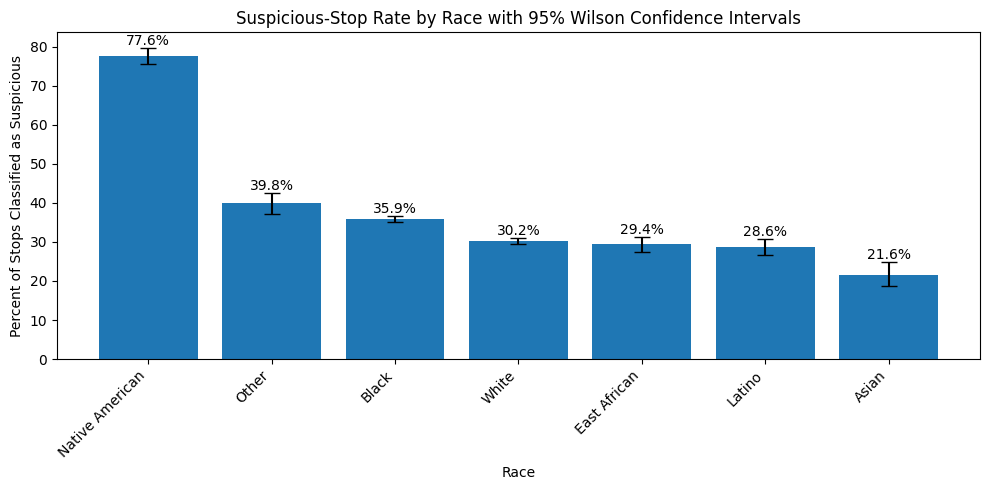

In [44]:
lower_error = race_suspicion_df["percent"] - race_suspicion_df["lower_percent"]
upper_error = race_suspicion_df["upper_percent"] - race_suspicion_df["percent"]
errors = [lower_error, upper_error]

plt.figure(figsize=(10, 5))

bars = plt.bar(
    race_suspicion_df["race"],
    race_suspicion_df["percent"],
    yerr=errors,
    capsize=6
)

plt.title("Suspicious-Stop Rate by Race with 95% Wilson Confidence Intervals")
plt.ylabel("Percent of Stops Classified as Suspicious")
plt.xlabel("Race")
plt.bar_label(bars, fmt="%.1f%%")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Findings

While Native Americans face a radically high rate of suspicious stops (~78%), they represent a small volume of total police stops, even when adjusting to their demographic representation. This exploration will prioritize the Black population since the univariate analysis showed that they are grossly overrepresented whe it comes to police stops.

In all, with a 95% confidence level, it can be concluded that the black population's suspicion stop confidence interval [35.1%-36.5%] is larger than that of White [29.3%-31.0%], East African [27.5%-31.3%], Latino [26.5%-30.6%], and Asian populations [18.6%-24.9%]. Paired with the extremely high Native American suspicion proportion, we have evidence that suggests that there is a disparity in stop types caused by race. To further analyze this disparity, we will perform a Chi-Squared test for Independence.

### Chi-Squared Test

A Chi-Squared Test for Independence will be performed to formally evaluate whether race and stop reason are dependent or independent.

Additionally, this test will focus only on the white and black population for the following two reasons:
1) The two populations are by far the most stopped, they combine for 78% of the total volume.
2) Certain populations - namely Native American and Asian - are radically far from the population mean (>10% distance).

* H<sub>o</sub>: The probability of a stop based off suspicion is independent of race (Black and White).
* H<sub>a</sub>: The probability of a stop based off suspicion is dependent on race.


In [45]:
# Main all-race chi-square test: race vs stop type
race_problem_table = pd.crosstab(
    df_race_problem["race"],
    df_race_problem["problem"]
)

display(race_problem_table)

race_problem_chi = Table(race_problem_table)
race_problem_result = race_problem_chi.test_nominal_association()

print("Chi-Squared Test for Independence: Race and Stop Type")
print(f"Statistic: {race_problem_result.statistic:.2f}")
print(f"Degrees of freedom: {race_problem_result.df}")
print(f"P-value: {race_problem_result.pvalue:.6g}")

expected_race_problem = pd.DataFrame(
    race_problem_chi.fittedvalues,
    index=race_problem_table.index,
    columns=race_problem_table.columns
)

print("\nSmallest expected count:")
print(expected_race_problem.min().min())

print("\nExpected counts:")
display(expected_race_problem.round(2))

print("\nStandardized residuals:")
display(race_problem_chi.standardized_resids.round(2))

# Focused Black/White follow-up
df_bw_problem = df_race_problem[df_race_problem["race"].isin(["Black", "White"])].copy()

bw_problem_table = pd.crosstab(
    df_bw_problem["race"],
    df_bw_problem["problem"]
)

display(bw_problem_table)

bw_problem_chi = Table(bw_problem_table)
bw_problem_result = bw_problem_chi.test_nominal_association()

print("\nFocused Black/White Chi-Squared Test: Race and Stop Type")
print(f"Statistic: {bw_problem_result.statistic:.2f}")
print(f"Degrees of freedom: {bw_problem_result.df}")
print(f"P-value: {bw_problem_result.pvalue:.6g}")

problem,suspicious,traffic
race,,
Asian,140,507
Black,5458,9762
East African,643,1545
Latino,531,1327
Native American,1177,339
Other,537,811
White,3536,8167


Chi-Squared Test for Independence: Race and Stop Type
Statistic: 1465.18
Degrees of freedom: 6
P-value: 0

Smallest expected count:
225.5868329466357

Expected counts:


problem,suspicious,traffic
race,,
Asian,225.59,421.41
Black,5306.69,9913.31
East African,762.88,1425.12
Latino,647.82,1210.18
Native American,528.58,987.42
Other,470.00,878.00
White,4080.44,7622.56



Standardized residuals:


problem,suspicious,traffic
race,,
Asian,-7.13,7.13
Black,3.44,-3.44
East African,-5.56,5.56
Latino,-5.85,5.85
Native American,35.74,-35.74
Other,3.91,-3.91
White,-12.99,12.99


problem,suspicious,traffic
race,,
Black,5458,9762
White,3536,8167



Focused Black/White Chi-Squared Test: Race and Stop Type
Statistic: 94.81
Degrees of freedom: 1
P-value: 0


#### Visualizing

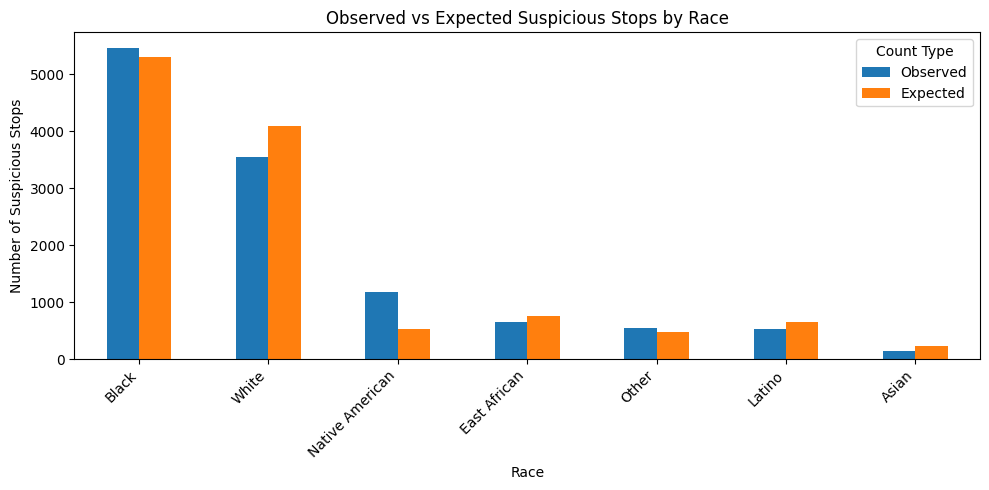

In [46]:
observed_race_problem = race_problem_chi.table_orig
expected_race_problem = race_problem_chi.fittedvalues

# Plot suspicious stops only
plot_data = pd.DataFrame({
    "Observed": observed_race_problem["suspicious"],
    "Expected": expected_race_problem["suspicious"]
})

plot_data = plot_data.sort_values("Observed", ascending=False)

ax = plot_data.plot(kind="bar", figsize=(10, 5))

plt.title("Observed vs Expected Suspicious Stops by Race")
plt.ylabel("Number of Suspicious Stops")
plt.xlabel("Race")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Count Type")
plt.tight_layout()
plt.show()

#### Findings

Given that the following values from the analysis:
* degrees of freedom = 1
* test statistic = 94.39

We can, at the 0.5% significance level, reject the null hypothesis that stop type and race are independent. Specifically, the analysis indicates that the Black population faces disproportionally more stops due to suspicions than they should if the two variables were independent. This suggests that the threshold for stops is lower for black individuals compared to whites.

## **Race and Person Searches**
#### (Bivariate and Chi-Squared

### What we are looking for:

From the previous analysis, we learned that there exists discrimination at the initialization of police stops. It is important to acknowledge that the stop is only the beginning of the interaction, thus, we seek to investigate if there exists discrimination in otehr portions of the interaction. This will be done by examining the relationship between race and person searches. This is because a person search is a physical and intrusive action: it represents escalation beyond a routine stop.

### Bivariate Analysis
We will begin with a confidence interval comparing race and person searches

In [47]:
# Analysis-specific cleaning: race and personSearch
df_race_search = df_base.dropna(subset=["race", "personSearch"]).copy()
df_race_search = df_race_search[df_race_search["race"] != "Unknown"].copy()

# Convert personSearch to Boolean
df_race_search["personSearch_bool"] = yes_no_to_bool(df_race_search["personSearch"])

# Keep only valid YES/NO values
df_race_search = df_race_search.dropna(subset=["personSearch_bool"]).copy()

results = []

# Get 95% Wilson confidence interval for person-search rate within each race
for race in df_race_search["race"].unique():
    subset = df_race_search[df_race_search["race"] == race]
    stop_count = len(subset)
    searched_count = subset["personSearch_bool"].sum()

    lower, upper = proportion_confint(
        count=searched_count,
        nobs=stop_count,
        alpha=0.05,
        method="wilson"
    )

    results.append({
        "race": race,
        "count": stop_count,
        "searched_count": searched_count,
        "search_rate": searched_count / stop_count,
        "lower": lower,
        "upper": upper
    })

race_search_df = pd.DataFrame(results).sort_values("search_rate", ascending=False)

race_search_df["percent"] = race_search_df["search_rate"] * 100
race_search_df["lower_percent"] = race_search_df["lower"] * 100
race_search_df["upper_percent"] = race_search_df["upper"] * 100

race_search_df

,race,count,searched_count,search_rate,lower,upper,percent,lower_percent,upper_percent
5,Native American,1516,464,0.306069,0.283384,0.329733,30.606860,28.338409,32.973345
2,Black,15220,3099,0.203614,0.197291,0.210086,20.361367,19.729139,21.008552
3,Other,1348,170,0.126113,0.109447,0.144904,12.611276,10.944665,14.490379
6,Latino,1858,221,0.118945,0.105006,0.134457,11.894510,10.500577,13.445686
4,Asian,647,62,0.095827,0.075473,0.120952,9.582689,7.547283,12.095205
0,White,11703,954,0.081518,0.076696,0.086613,8.151756,7.669632,8.661344
1,East African,2188,168,0.076782,0.066353,0.088695,7.678245,6.635334,8.869503


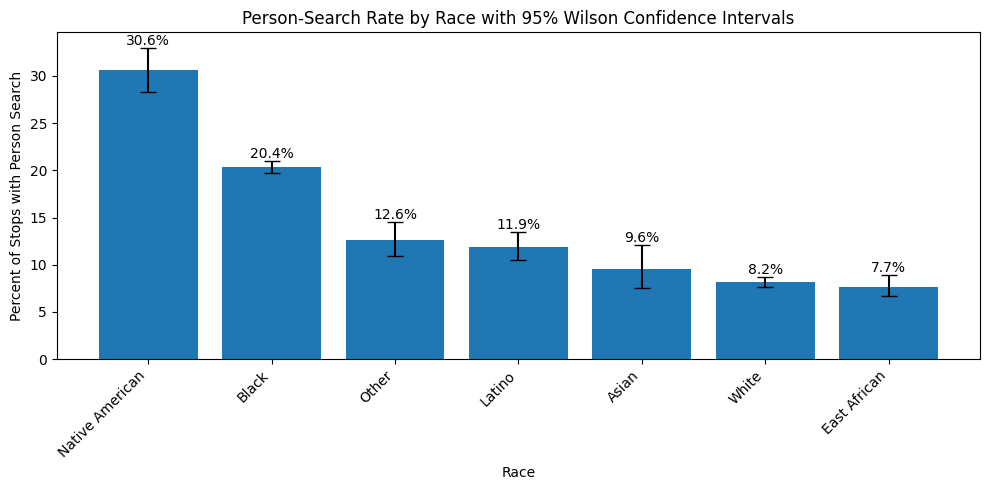

In [48]:
lower_error = race_search_df["percent"] - race_search_df["lower_percent"]
upper_error = race_search_df["upper_percent"] - race_search_df["percent"]
errors = [lower_error, upper_error]

plt.figure(figsize=(10, 5))

bars = plt.bar(
    race_search_df["race"],
    race_search_df["percent"],
    yerr=errors,
    capsize=6
)

plt.title("Person-Search Rate by Race with 95% Wilson Confidence Intervals")
plt.ylabel("Percent of Stops with Person Search")
plt.xlabel("Race")
plt.bar_label(bars, fmt="%.1f%%")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Findings

We can again observe extreme results for the Native American population, but they will again be discarded due to previous discussions. Perhaps another exploration of this data should seek to understand the results for this population.

In all, with a 95% confidence level, it can be concluded that the black population's person search frequency [19.7%-21.0%] is substantially larger than that of White [7.7%-8.7%], East African [6.6%-8.9%], Latino [10.5%-13.5%], and Asian populations [7.6%-12.1%]. Thus, we have evidence that suggests that there is a disparity in person search frequency caused by race. To further analyze this disparity, we will perform a Chi-Squared test for Independence.

### Chi-Squared Test

A Chi-Squared Test for Independence will be performed to formally evaluate whether race and stop reason are dependent or independent.

For similar reasons as the previous Chi-Squared Test, this test will exclude the Native American population. All other categories will be included in the test.

* H<sub>o</sub>: The probability of a person search is independent of race.
* H<sub>a</sub>: The probability of a person search is dependent on race.


In [49]:
# Main all-race chi-square test: race vs person search
race_search_table = pd.crosstab(
    df_race_search["race"],
    df_race_search["personSearch_bool"]
)

display(race_search_table)

# Conditional percentage table
race_search_percent = pd.crosstab(
    df_race_search["race"],
    df_race_search["personSearch_bool"],
    normalize="index"
) * 100

print("Conditional percent table:")
display(race_search_percent.round(2))

race_search_chi = Table(race_search_table)
race_search_result = race_search_chi.test_nominal_association()

print("Chi-Squared Test for Independence: Race and Person Search")
print(f"Statistic: {race_search_result.statistic:.2f}")
print(f"Degrees of freedom: {race_search_result.df}")
print(f"P-value: {race_search_result.pvalue:.6g}")

expected_race_search = pd.DataFrame(
    race_search_chi.fittedvalues,
    index=race_search_table.index,
    columns=race_search_table.columns
)

print("\nSmallest expected count:")
print(expected_race_search.min().min())

print("\nExpected counts:")
display(expected_race_search.round(2))

print("\nStandardized residuals:")
display(race_search_chi.standardized_resids.round(2))

# Focused Black/White follow-up
df_bw_search = df_race_search[df_race_search["race"].isin(["Black", "White"])].copy()

bw_search_table = pd.crosstab(
    df_bw_search["race"],
    df_bw_search["personSearch_bool"]
)

display(bw_search_table)

bw_search_chi = Table(bw_search_table)
bw_search_result = bw_search_chi.test_nominal_association()

print("\nFocused Black/White Chi-Squared Test: Race and Person Search")
print(f"Statistic: {bw_search_result.statistic:.2f}")
print(f"Degrees of freedom: {bw_search_result.df}")
print(f"P-value: {bw_search_result.pvalue:.6g}")

personSearch_bool,False,True
race,,
Asian,585,62
Black,12121,3099
East African,2020,168
Latino,1637,221
Native American,1052,464
Other,1178,170
White,10749,954


Conditional percent table:


personSearch_bool,False,True
race,,
Asian,90.42,9.58
Black,79.64,20.36
East African,92.32,7.68
Latino,88.11,11.89
Native American,69.39,30.61
Other,87.39,12.61
White,91.85,8.15


Chi-Squared Test for Independence: Race and Person Search
Statistic: 1196.41
Degrees of freedom: 6
P-value: 0

Smallest expected count:
96.41200696055685

Expected counts:


personSearch_bool,False,True
race,,
Asian,550.59,96.41
Black,12952.01,2267.99
East African,1861.96,326.04
Latino,1581.13,276.87
Native American,1290.09,225.91
Other,1147.13,200.87
White,9959.09,1743.91



Standardized residuals:


personSearch_bool,False,True
race,,
Asian,3.84,-3.84
Black,-25.31,25.31
East African,9.80,-9.80
Latino,3.74,-3.74
Native American,-17.56,17.56
Other,2.41,-2.41
White,25.23,-25.23


personSearch_bool,False,True
race,,
Black,12121,3099
White,10749,954



Focused Black/White Chi-Squared Test: Race and Person Search
Statistic: 771.25
Degrees of freedom: 1
P-value: 0


#### Visualizing

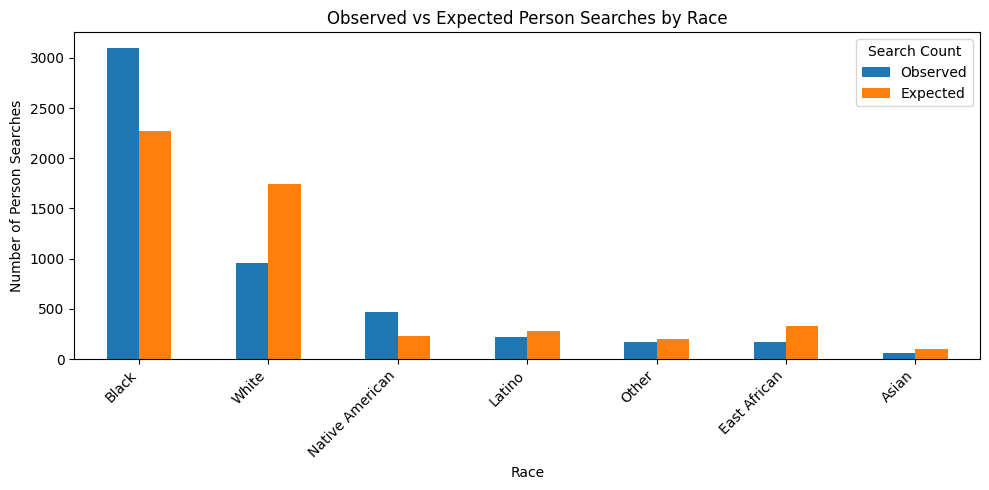

In [50]:
observed_race_search = race_search_chi.table_orig
expected_race_search = race_search_chi.fittedvalues

# Plot person searches only
plot_data = pd.DataFrame({
    "Observed": observed_race_search[True],
    "Expected": expected_race_search[True]
})

plot_data = plot_data.sort_values("Observed", ascending=False)

ax = plot_data.plot(kind="bar", figsize=(10, 5))

plt.title("Observed vs Expected Person Searches by Race")
plt.ylabel("Number of Person Searches")
plt.xlabel("Race")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Search Count")
plt.tight_layout()
plt.show()

#### Findings

Given that the following values from the analysis:
* degrees of freedom = 5
* test statistic = 921.63

We can, at the 0.5% significance level, reject the null hypothesis that the probability of a person search is independent of race. Specifically, the analysis indicates that the Black population faces disproportionally more person searches than they should if the two variables were independent. This suggests that officers are more likely to escalate interactions with the Black population: this could potentially be caused by discrimination.

## **Now What? Extra Mile?**

So far in our investigation into the effects of race in police stops, we have built a strong case for the existence of significant racial discrimination. This discrimination seems to negatively affect the black population more than the others. This claim is supported by these three observations from this exploration:

1) The black population is severely overrepresented in the raw volume of police stops
2) Blacks are significanlty more likely to be stopped from suspicion than most other races (Native Americans are the only exception)
3) Blacks individuals are significantly more likely to be searched than most other races (Native Americans are the only exception)

Although these three observations strongly suggest that racial discrimination by the police force is a real and significant problem, they do not prove it. There various angles through which a skeptic could question this conclusion. Some of these angles cannot be investigated with this data set: they mark true limitations to this exploration. Here are some examples of questions that might be worth investigating if data that allowed it existed:
1) What behaviors are deemed "suspicious", do they relate to race?
2) How does the driver act during the police stop?

While we cannot experiment with every idea, there are confounding variables in this data set that can be explored. What we will test is whether the location plays a role in explaining what happens during a police stop. A skeptic's question we want to answer here would be something along the lines of: 
* "There is no discrimination based mainly around race. Certain areas have more crime, and these areas just happen to have more residents of minority populations."

### Person Search Disparity Ratio Per Precinct

To investigate the previous concern, we weill be analysing the person search disparity ratio per precinct. In all, three variables will be used: Person Search, Race, and Precinct. Overall, we want to examine whether the location within the city has an impact in the disparity between black and white drivers that get a person search.
1) If we find that there is no difference between the disparity across precincts, this adds strength to the idea that race can directly stop outcomes.
2) If there is a difference between the disparity across precincts, then it might suggest that the location is a confounding variable.

#### Breslow-Day Test
To make this analysis, we will cover a test that is not covered in class: the Breslow-Day test. This is a test for homogeneity. The key difference between this test and the Chi-Squared Test for Homogeneity is that while the Chi-Squared test compares whether proportions differ across groups - it is fundamentally a two-dimensional test - the Breslow-Day test, on the other hand, is three-dimensional. It compares the homogeneity of "odds ratios" - which are composed of a 2x2 table (in our case white/black x search/no-search) - among "strata" (in our case, precincts).

* H<sub>o</sub>: The disparity among white and black searches is homogeneous across all precincts.
* H<sub>a</sub>: The disparity among white and black searches changes across precincts.


#### Performing Breslow-Day Test

In [51]:
# Analysis-specific cleaning: Black/White, personSearch, precinct
df_bw_precinct = df_base.dropna(subset=["race", "personSearch", "policePrecinct"]).copy()

df_bw_precinct = df_bw_precinct[df_bw_precinct["race"].isin(["Black", "White"])].copy()

df_bw_precinct["personSearch_bool"] = yes_no_to_bool(df_bw_precinct["personSearch"])
df_bw_precinct = df_bw_precinct.dropna(subset=["personSearch_bool"]).copy()

# Create stratified table by precinct
strat_table = StratifiedTable.from_data(
    "personSearch_bool",
    "race",
    "policePrecinct",
    data=df_bw_precinct
)

print("---- Test of Equal Black/White Odds Ratios Across Precincts ----")
try:
    equal_odds_result = strat_table.test_equal_odds()
    print(equal_odds_result)
except AttributeError:
    print("Your statsmodels version does not support test_equal_odds().")
    print("Use the precinct-specific odds ratios below instead.")

print("\n---- Mantel-Haenszel Test: Common Odds Ratio = 1 ----")
print(strat_table.test_null_odds())

print("\n---- Pooled Black/White Odds Ratio ----")
print(strat_table.oddsratio_pooled)

# Organize counts by precinct, race, and person search
breslow_table = pd.crosstab(
    df_bw_precinct["policePrecinct"],
    [df_bw_precinct["race"], df_bw_precinct["personSearch_bool"]]
)

display(breslow_table)

# Extract counts
b_true = breslow_table[("Black", True)]
b_false = breslow_table[("Black", False)]
w_true = breslow_table[("White", True)]
w_false = breslow_table[("White", False)]

# Check for zero cells
has_zero_cell = (breslow_table == 0).any().any()

if has_zero_cell:
    print("At least one cell is zero. Using 0.5 continuity correction for odds ratios.")
    odds_ratios = ((b_true + 0.5) / (b_false + 0.5)) / ((w_true + 0.5) / (w_false + 0.5))
else:
    odds_ratios = (b_true / b_false) / (w_true / w_false)

odds_ratios = odds_ratios.sort_values(ascending=False)

print("\n---- Black/White Person-Search Odds Ratio by Precinct ----")
display(odds_ratios)

---- Test of Equal Black/White Odds Ratios Across Precincts ----
pvalue      8.55505960517533e-06
statistic   28.80717632648738

---- Mantel-Haenszel Test: Common Odds Ratio = 1 ----
pvalue      0.0
statistic   377.40237442130916

---- Pooled Black/White Odds Ratio ----
0.453905789752999


race              Black       White      
personSearch_bool False True  False True 
policePrecinct                           
1                  1606   570  1207   161
2                  1924   302  3063   241
3                  1600   459  1132   179
4                  4745  1438  1022   171
5                  2246   330  4325   202


---- Black/White Person-Search Odds Ratio by Precinct ----


policePrecinct
5    3.145857
1    2.660791
2    1.994949
3    1.814204
4    1.811246
dtype: float64

#### Visualizing
* Visualizing this data requires us to link the data with a map of Minneapolis. [This](https://opendata.minneapolismn.gov/datasets/cityoflakes::minneapolis-police-precincts/about) resouce was used.
* Since the resource is from the Minneapolis government itself, we can assume that the Precinct numbers (1-5) in both the MplsStops and Map refer to the same place.

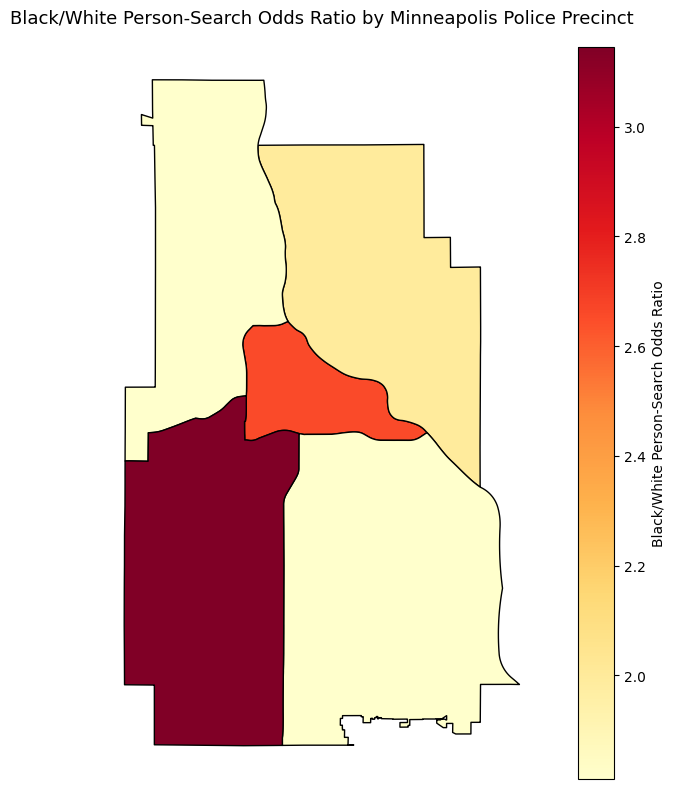

In [52]:
import geopandas as gpd

# Load precinct shapefile
shape_path = Path("Police_Precincts.shp")

if not shape_path.exists():
    raise FileNotFoundError(
        "Police_Precincts.shp was not found. Make sure the shapefile and its related files are in the project folder."
    )

precinct_map = gpd.read_file(shape_path)

# Set PRECINCT column to correct datatype
precinct_map["PRECINCT"] = precinct_map["PRECINCT"].astype(int)

# Convert odds ratios into dataframe for merging
map_data = odds_ratios.rename("odds_ratio").rename_axis("PRECINCT").reset_index()
map_data["PRECINCT"] = map_data["PRECINCT"].astype(int)

# Merge map with odds-ratio data
merged_map = precinct_map.merge(
    map_data,
    on="PRECINCT",
    how="left"
)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))

merged_map.plot(
    column="odds_ratio",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    legend_kwds={"label": "Black/White Person-Search Odds Ratio"},
    ax=ax
)

plt.title("Black/White Person-Search Odds Ratio by Minneapolis Police Precinct", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### Findings:

At the 5% significance level, we have sufficient evidence to reject the null hypothesis, and that the disparity among white and black searches in Minneapolis is heterogeneous across precincts. This means that the location is, in fact, a confounding variable in this data set and exploration. 

Thus, this indicates that there is some evidence to support skeptics that believe the racial disparities in police stops are a byproduct of racial demographics in higher-crime precincts. While this test shows that the location can compound the disparity, the reality is that the odds ratio is strongly above 1.0 in every precinct. In other words, black individuals are searched more than white individuals regardless of location.

## **Conclusions**

The following insights about Minneapolis stops have been drawn from the data:
* The black population is overrepresented in Minneapolis police stops
* The black population faces more police stops on the grounds of suspicion than expected in a race-blind setting
* The black population faces more person searches than expected in a race-blind setting
* Location is a confounding variable to race when observing person searches. Though, regardless of location, race is still a major predictor of search probability as the odds of a black individual being searched are significantly higher than that of a white individual on all precincts.

Where to go from here
* Although this exploration shows a high relationship between race and police stop causation and outcomes, further analysis must be done to strengthen this relationship. In particular, other data such as precinct racial demographic, precinct crime rates, and more details into driver behavior before and during the stop can prove to be valuable 